<a href="https://colab.research.google.com/github/SujalGodse/Advance-Analytics-using-Statistics/blob/main/Unsupervised_Day25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Unsupervised Learning**

# **K Means Clusturing**

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
import sklearn
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression


import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
from numpy import random
from collections import Counter
from numpy.linalg import inv
from numpy.linalg import eig
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel
import scipy
from scipy import stats
from scipy.stats import binom,poisson,norm,t,expon,f
from sklearn.model_selection import train_test_split

import statsmodels
from statsmodels import stats
from statsmodels.stats import weightstats as ssw

import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp

from statsmodels.discrete.discrete_model import MNLogit

from sklearn.tree import DecisionTreeClassifier

import statsmodels.stats
from statsmodels.stats.proportion import proportions_ztest

from scipy.stats import chisquare

from scipy.stats import chi2_contingency

from statsmodels.stats import rates
from statsmodels.stats.rates import test_poisson

from statsmodels.stats.rates import test_poisson_2indep

from scipy.stats import chi2

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/CDAC/CDAC_DataBook.xlsx',sheet_name='clusters')
df.shape

(30, 2)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
df_scaled = ss.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled,columns=df.columns,index=df.index)

km = KMeans(n_clusters=3)
mod1 = km.fit(df_scaled)

In [ ]:
mod1.cluster_centers_       # centroids

array([[-1.08473514,  1.04670987],
       [ 0.0471624 , -1.17533099],
       [ 1.03757274,  0.12862113]])

the centroids are sandardized value and now if we have to convert in into x (actual value) or on original scale then we rearrange standardscale formula. Below are manual calculation

ss = x - mean / std

x = ss * std + mean

In [ ]:
# converting standardized centroid values into actual value using python
cc_center = mod1.cluster_centers_
cc_center = pd.DataFrame(cc_center,columns=df.columns)
ss.inverse_transform(cc_center)

array([[29.6, 66.8],
       [43.2, 16.7],
       [55.1, 46.1]])

In [ ]:
mydata = pd.DataFrame([[28,72],[40,20],[58,45]],columns=df.columns)
mydata_scaled = ss.transform(mydata)
mod1.predict(mydata_scaled)

array([0, 1, 2], dtype=int32)

**Note : fit_transform() is used with training data and transform() with test data**

In [ ]:
mod1.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

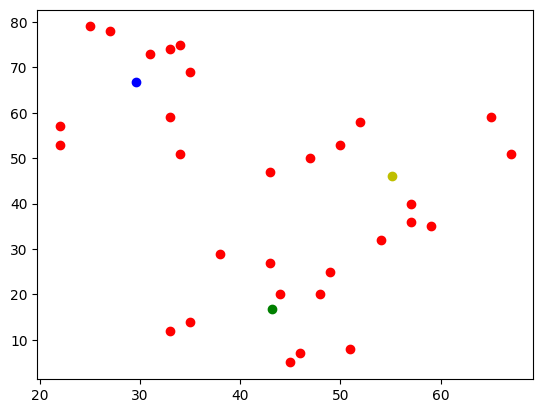

In [ ]:
plt.scatter(df['Var1'],df['Var2'],c='r')
plt.scatter(43.2, 16.7,c='g')
plt.scatter(29.6, 66.8,c='b')
plt.scatter(55.1, 46.1,c='y')

In [ ]:
mod1.inertia_     # gives within cluster variations

12.510203077852196

In [ ]:
wcv = []
for ctr in range(2,16):
  km = KMeans(n_clusters=ctr)
  mod1 = km.fit(df_scaled)
  wcv.append(mod1.inertia_)

wcv

[25.91622200066813,
 12.510203077852196,
 9.725815666335311,
 8.22435280626313,
 6.278670598727362,
 4.768942545937627,
 3.251223734736024,
 2.2848726665337398,
 1.9391173183945745,
 1.2668230996541432,
 0.970357433772816,
 0.9813145459523416,
 0.6737673521139306,
 0.6196808904763826]

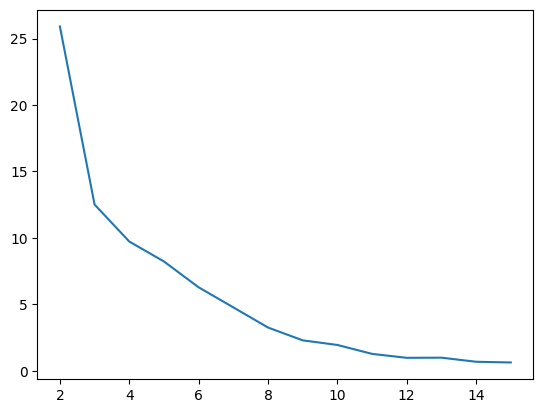

In [ ]:
plt.plot(list(range(2,16)),wcv)
plt.show()

## Problem on dbscan dataset

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/CDAC/CDAC_DataBook.xlsx',sheet_name='dbscan')

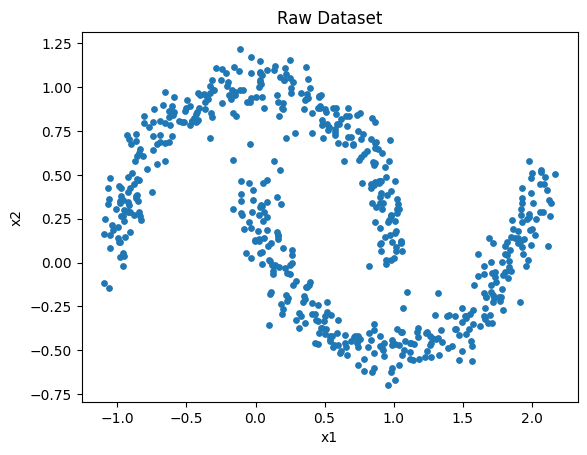

In [ ]:
plt.figure()
plt.scatter(df['x1'],df['x2'],s=15)
plt.title('Raw Dataset')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

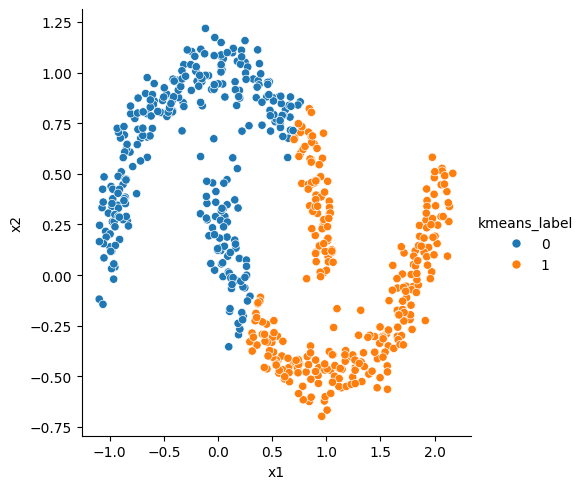

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2)
df["kmeans_label"] = kmeans.fit_predict(df[["x1", "x2"]])
sns.relplot(x='x1',y='x2',data=df,hue='kmeans_label')

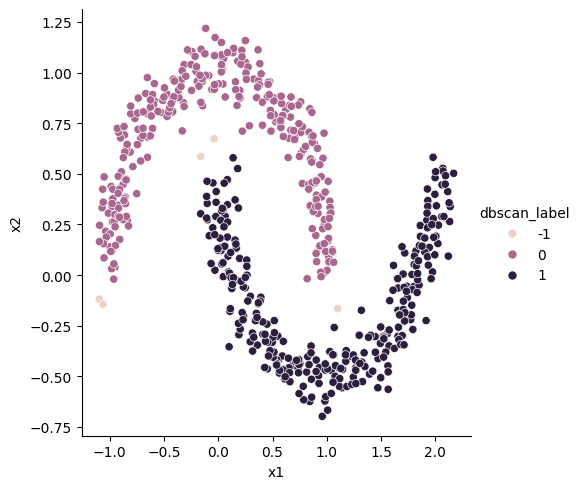

In [ ]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.15,min_samples=8)
df["dbscan_label"] = dbscan.fit_predict(df[["x1", "x2"]])
sns.relplot(x='x1',y='x2',data=df,hue='dbscan_label')

---

# **Hierarchical Clustering**

Hierarchical Clustering is an Unsupervised Machine Learning algorithm that groups similar data points into clusters and creates a tree-like structure called a Dendrogram.

Unlike K-Means, it does not initially require assigning points to clusters.

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/CDAC/CDAC_DataBook.xlsx',sheet_name='mtcars')
df.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


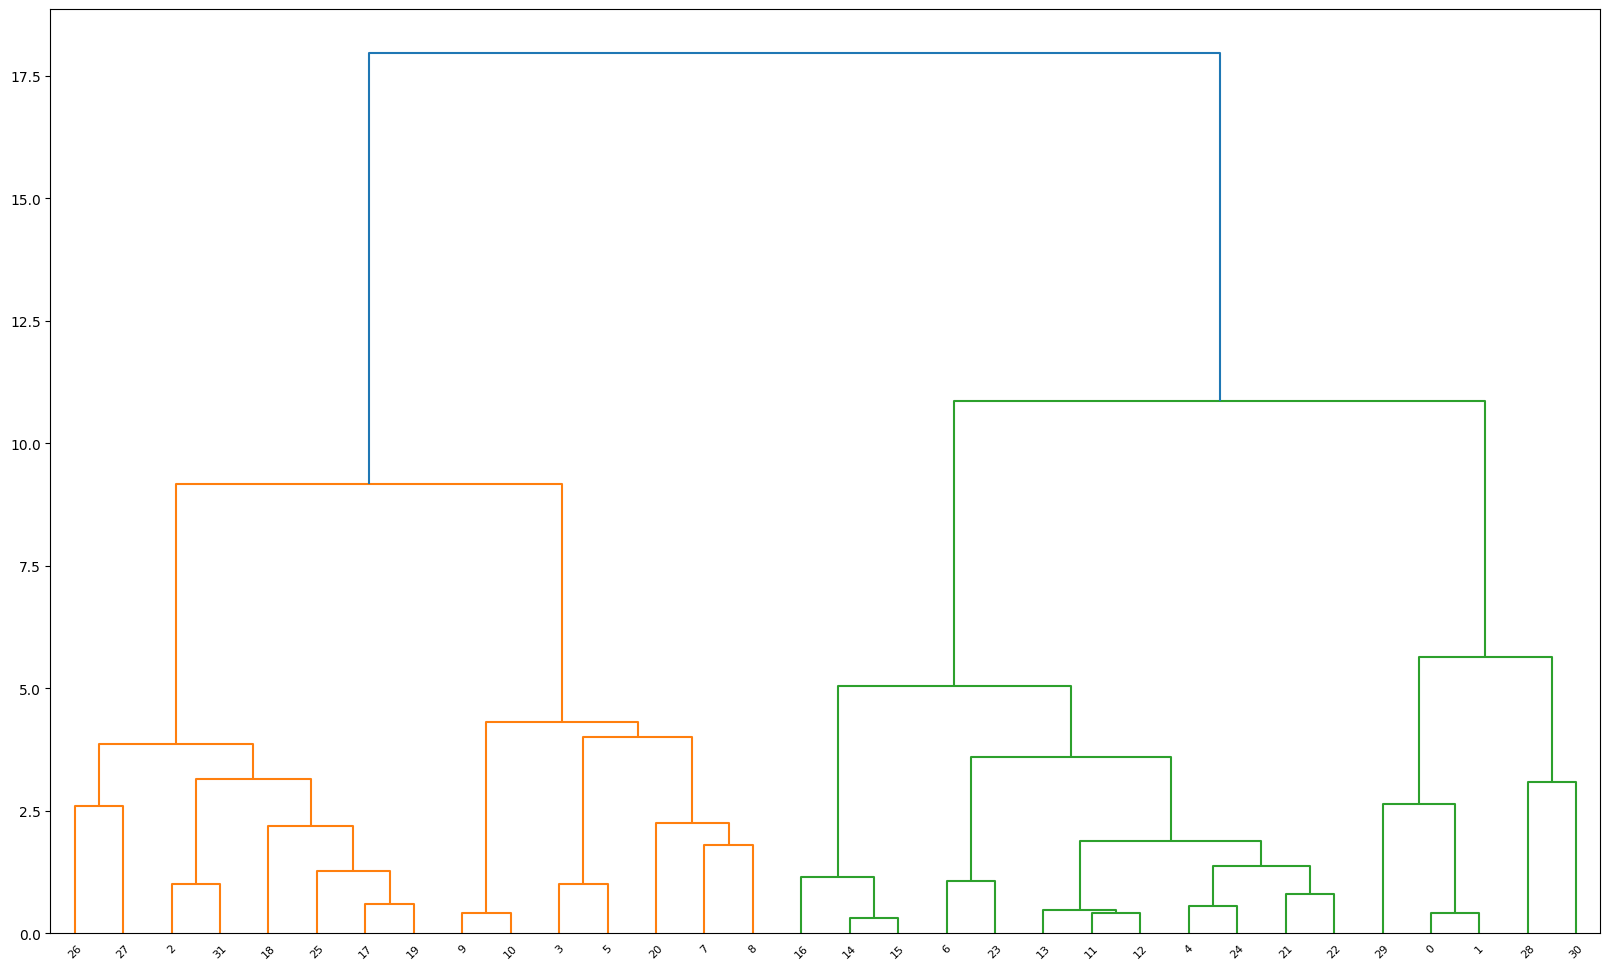

In [ ]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

ss = StandardScaler()
df_scaled = ss.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled,columns=df.columns,index=df.index)
plt.figure(figsize=(20,12))
dend = sch.dendrogram(sch.linkage(df_scaled, method = 'ward'))
plt.show()

# **Principal Component Analysis**

PCA is one of the most important Dimensionality Reduction techniques in Machine Learning.

Definition

PCA transforms a dataset with many features into a smaller set of new features called Principal Components, while retaining as much information (variance) as possible.

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/CDAC/pca.xlsx')
df.shape

(500, 7)

In [ ]:
from sklearn.metrics import confusion_matrix
x = df.drop('Response', axis=1)
y = df.Response

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=20)

x_train = sm.add_constant(x_train, prepend=False)

mod1 = sm.Logit(y_train,x_train).fit()

x_test = sm.add_constant(x_test, prepend=False)
y_pred = mod1.predict(x_test)
y_pred = (y_pred>=0.5).astype(int)

print(confusion_matrix(y_test,y_pred))

Optimization terminated successfully.
         Current function value: 0.170808
         Iterations 10
[[49  4]
 [ 3 44]]


In [ ]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(x_train)

PCA()

In [ ]:
pca.components_

array([[ 3.62667387e-01,  3.25018806e-01,  3.08258520e-01,
         2.84952769e-01,  5.67354109e-01,  5.14512450e-01,
         7.48939542e-18],
       [ 6.23481999e-01,  5.72119188e-01, -3.24867045e-01,
        -3.02616162e-01, -2.17149861e-01, -1.99199980e-01,
        -4.73223974e-17],
       [ 1.59466721e-01,  1.46178051e-01,  5.78474380e-01,
         5.40355427e-01, -4.16981407e-01, -3.90784152e-01,
         6.44193422e-17],
       [-4.94002455e-01,  5.38206918e-01, -1.34609266e-01,
         1.40723639e-01,  4.45087230e-01, -4.79863989e-01,
         3.43191156e-15],
       [-4.49938573e-01,  4.96025113e-01,  2.71239961e-01,
        -2.82452986e-01, -4.25013625e-01,  4.66397877e-01,
         3.18487933e-15],
       [-8.84860605e-02,  9.98338036e-02, -6.10831163e-01,
         6.60044361e-01, -2.79897366e-01,  3.08362815e-01,
         8.97801771e-15],
       [ 3.93931798e-15, -4.30794516e-15,  5.02720645e-15,
        -5.56052635e-15,  2.35137708e-15, -2.59516295e-15,
         1.0000000

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}'for i in range(len(pca.components_))],
    index=x_train.columns
    )

print(loadings)

                PC1           PC2           PC3           PC4           PC5  \
X1     3.626674e-01  6.234820e-01  1.594667e-01 -4.940025e-01 -4.499386e-01   
X2     3.250188e-01  5.721192e-01  1.461781e-01  5.382069e-01  4.960251e-01   
X3     3.082585e-01 -3.248670e-01  5.784744e-01 -1.346093e-01  2.712400e-01   
X4     2.849528e-01 -3.026162e-01  5.403554e-01  1.407236e-01 -2.824530e-01   
X5     5.673541e-01 -2.171499e-01 -4.169814e-01  4.450872e-01 -4.250136e-01   
X6     5.145125e-01 -1.992000e-01 -3.907842e-01 -4.798640e-01  4.663979e-01   
const  7.489395e-18 -4.732240e-17  6.441934e-17  3.431912e-15  3.184879e-15   

                PC6           PC7  
X1    -8.848606e-02  3.939318e-15  
X2     9.983380e-02 -4.307945e-15  
X3    -6.108312e-01  5.027206e-15  
X4     6.600444e-01 -5.560526e-15  
X5    -2.798974e-01  2.351377e-15  
X6     3.083628e-01 -2.595163e-15  
const  8.978018e-15  1.000000e+00  


In [ ]:
pca = PCA(n_components=2)
pca.fit(x_train)
pca.components_

array([[ 3.62667387e-01,  3.25018806e-01,  3.08258520e-01,
         2.84952769e-01,  5.67354109e-01,  5.14512450e-01,
         7.48939542e-18],
       [ 6.23481999e-01,  5.72119188e-01, -3.24867045e-01,
        -3.02616162e-01, -2.17149861e-01, -1.99199980e-01,
        -4.73223974e-17]])

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}'for i in range(len(pca.components_))],
    index=x_train.columns
    )

print(loadings)

                PC1           PC2
X1     3.626674e-01  6.234820e-01
X2     3.250188e-01  5.721192e-01
X3     3.082585e-01 -3.248670e-01
X4     2.849528e-01 -3.026162e-01
X5     5.673541e-01 -2.171499e-01
X6     5.145125e-01 -1.992000e-01
const  7.489395e-18 -4.732240e-17
